In [6]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
 
# ===========================
# 1. 데이터 로드
# ===========================
df = pd.read_csv('penguins.csv', index_col=0)

In [ ]:

df = df.dropna() # 결측치 행 제거
df = df.drop(columns=['year'],errors='ignore') # 불필요한 컬럼 제거

print("=== 변환 전 (Categorical) ===")
print(df[['species', 'island', 'sex']].head())

le = LabelEncoder()

df['species'] = le.fit_transform(df['species']) # Adelie=0, Chinstrap=1, Gentoo=2
df['island'] = le.fit_transform(df['island']) # Biscoe=0, Dream=1, Torgersen=2
df['sex'] = le.fit_transform(df['sex']) # female=0, male=1

print("\n=== 변환 후 (Numerical) ===")
print(df[['species', 'island', 'sex']].head())

# X, y 분리
X = df.drop(columns=['species'])   # 입력 데이터
y = df['species']                  # 정답 라벨

# Random Forest 학습
model = RandomForestClassifier(random_state=42)
model.fit(X, y)

# Feature Importance 확인
importances = model.feature_importances_

result = pd.DataFrame({
    'feature': X.columns,
    'importance': importances
}).sort_values(by='importance', ascending=False,).reset_index(drop=True)


print(result)


=== 변환 전 (Categorical) ===
   species  island  sex
1        0       2    1
2        0       2    0
3        0       2    0
5        0       2    0
6        0       2    1

=== 변환 후 (Numerical) ===
   species  island  sex
1        0       2    1
2        0       2    0
3        0       2    0
5        0       2    0
6        0       2    1
             feature  importance
0     bill_length_mm    0.357832
1  flipper_length_mm    0.247718
2      bill_depth_mm    0.151929
3        body_mass_g    0.118372
4             island    0.115853
5                sex    0.008297


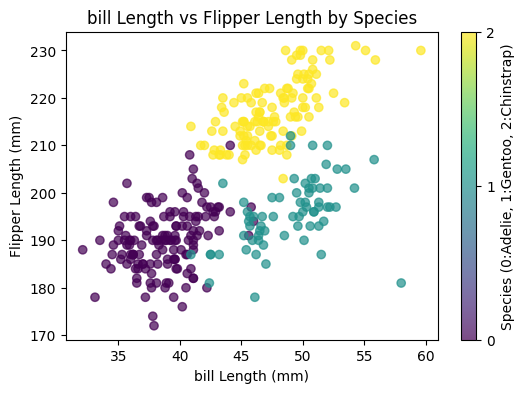

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
scatter = plt.scatter(df['bill_length_mm'], df['flipper_length_mm'], c=df['species'], cmap='viridis', alpha=0.7)

plt.xlabel('bill Length (mm)')
plt.ylabel('Flipper Length (mm)')
plt.title('bill Length vs Flipper Length by Species')

plt.colorbar(scatter, ticks=[0,1,2], label='Species (0:Adelie, 1:Gentoo, 2:Chinstrap)')
plt.show()

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. 특성(X)과 타겟(y) 분리
# 'species' 컬럼이 타겟(예측해야 할 값)이고, 나머지가 특성(입력값)
X = df.drop('species', axis=1).values
y = df['species'].values

# 2. 학습/테스트 데이터 분할 (7:3 비율)
# 일반화 성능 평가를 위해 데이터를 나눈다.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

# 3. 데이터 스케일링 (StandardScaler)
sc = StandardScaler()
X_train_std = sc.fit_transform(X_train) # 학습 데이터로 스케일러 학습 및 변환
X_test_std = sc.transform(X_test)       # 테스트 데이터는 변환만 수행

print("=== 데이터 스케일링 완료 ===")
print("학습 데이터 크기(X_train_std):", X_train_std.shape)
print("테스트 데이터 크기(X_test_std):", X_test_std.shape)
print(df.columns.tolist())

=== 데이터 스케일링 완료 ===
학습 데이터 크기(X_train_std): (233, 6)
테스트 데이터 크기(X_test_std): (100, 6)
['species', 'island', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex']


In [10]:
# 모델 생성

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=1),
    "Decision Tree": DecisionTreeClassifier(random_state=1),
    "SVM": SVC(kernel='rbf', probability=True, random_state=1),
    "Voting Ensemble": VotingClassifier(
        estimators=[
            ('lr', LogisticRegression(max_iter=1000, random_state=1)),
            ('dt', DecisionTreeClassifier(random_state=1)),
            ('svm', SVC(kernel='rbf', probability=True, random_state=1))
        ],
        voting='soft'  
    )
}

In [ ]:
# 모델 학습 및 예측
predictions = {}

for model_name, model in models.items():
    model.fit(X_train_std, y_train)          
    y_pred = model.predict(X_test_std)       
    predictions[model_name] = y_pred        

print("모델 학습 및 예측 완료")

모델 학습 및 예측 완료


In [ ]:
# 평가 지표 계산

from sklearn.metrics import accuracy_score, confusion_matrix, f1_score

results = []

for model_name, y_pred in predictions.items():
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    cm = confusion_matrix(y_test, y_pred)

    results.append({
        "Model": model_name,
        "Accuracy": acc,
        "F1-score": f1,
        "Confusion Matrix": cm
    })

In [ ]:
# 결과 비교

import pandas as pd

result_df = pd.DataFrame(results)

print("=== 모델별 성능 비교 ===")
print(result_df[["Model", "Accuracy", "F1-score"]])

print("\n=== 모델별 Confusion Matrix ===")
for result in results:
    print(f"\n[{result['Model']}]")
    print(result["Confusion Matrix"])

=== 모델별 성능 비교 ===
                 Model  Accuracy  F1-score
0  Logistic Regression      0.97  0.969289
1        Decision Tree      0.94  0.939211
2                  SVM      0.97  0.969289
3      Voting Ensemble      0.97  0.969289

=== 모델별 Confusion Matrix ===

[Logistic Regression]
[[43  0  0]
 [ 3 17  0]
 [ 0  0 37]]

[Decision Tree]
[[40  1  2]
 [ 3 17  0]
 [ 0  0 37]]

[SVM]
[[43  0  0]
 [ 3 17  0]
 [ 0  0 37]]

[Voting Ensemble]
[[43  0  0]
 [ 3 17  0]
 [ 0  0 37]]


In [ ]:
# Cross-Validation을 통한 일반화 성능 확인

from sklearn.model_selection import cross_val_score
import pandas as pd

cv_results = []

for model_name, model in models.items():
    scores = cross_val_score(
        model,
        X_train_std,
        y_train,
        cv=5,
        scoring='accuracy'
    )

    cv_results.append({
        "Model": model_name,
        "CV Mean Accuracy": scores.mean(),
        "CV Std": scores.std()
    })

cv_result_df = pd.DataFrame(cv_results)

print("=== Cross-Validation 결과 ===")
print(cv_result_df)

=== Cross-Validation 결과 ===
                 Model  CV Mean Accuracy    CV Std
0  Logistic Regression          0.995652  0.008696
1        Decision Tree          0.978631  0.013458
2                  SVM          0.995652  0.008696
3      Voting Ensemble          0.991397  0.010538
